# GSB 5544 — PA 2.1: Data Visualization Using `plotnine` and the Grammar of Graphics — SOLUTION



> *Many ways to the top of the mountain — choose one. Many ways to the top of the mountain — know many.*

Say this out loud: **"Many ways of doing plots in Python we have."**

There are:
1. Using Matplotlib
2. Using Seaborn
3. Using Plotly

...to name a few. We are going to explore **plotnine**, a package that closely follows the **grammar of graphics** used in `ggplot2` in R.


## Cars Data

The Palmer Penguins dataset had a variety of column types with which to explore some nice visualizations. The `mtcars` dataset is another popular dataset for doing some simple data work, but does not contain the same types of variables.

Run the following code to load the `mtcars` dataset and explore the observations and variables contained within. To learn more about this dataset check out [this site](https://stat.ethz.ch/R-manual/R-devel/library/datasets/html/mtcars.html)

In [1]:
import statsmodels.api as sm
import pandas as pd

mtcars = sm.datasets.get_rdataset("mtcars", "datasets", cache=True).data
df = pd.DataFrame(mtcars)

In [2]:
df

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
rownames,,,,,,,,,,,
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2
...,...,...,...,...,...,...,...,...,...,...,...
Lotus Europa,30.4,4,95.1,113,3.77,1.513,16.90,1,1,5,2
Ford Pantera L,15.8,8,351.0,264,4.22,3.170,14.50,0,1,5,4
Ferrari Dino,19.7,6,145.0,175,3.62,2.770,15.50,0,1,5,6


The statement "the `mtcars` dataset does not contain the same types of variables as the penguins dataset" is a little true and a little false. There are no variables that contain text values, BUT there are variables that it makes sense to consider categorical variables. In most situations, it makes sense to treat the values of categorical variables as text values instead of numeric values.

Some of these variables, like the `cyl` variable, have numeric values that actually make sense as numbers (i.e. the number of cylinders in the engine). However, it doesn't make the most sense to "do math" with this type of variable (e.g. take averages and such) because there are so few different value this can take on AND they're an explicit choice made by the car manufacturer. So, it makes more sense to treat the `cyl` variable as a categorical variable despite it having numeric values.

You will need to keep these kinds of nuances about data in mind as you work with an increasing variety and richness of data, and do more complex things with them

Use the `astype()` method to convert the categorical variables of the `mtcars` (df) dataset to have text values in the code chunk below. We've done one for you!

In [3]:
df["am"] = df["am"].astype(str)

# Convert the other variables below
df["cyl"]  = df["cyl"].astype(str)
df["vs"]   = df["vs"].astype(str)
df["gear"] = df["gear"].astype(str)
df["carb"] = df["carb"].astype(str)
df.dtypes

mpg     float64
cyl      object
disp    float64
hp        int64
drat    float64
wt      float64
qsec    float64
vs       object
am       object
gear     object
carb     object
dtype: object

**Answer:** After converting, `df.dtypes` shows these columns as `object` (text). Printing the data frame alone does *not* make the change obvious — `"4"` prints exactly like `4` — so check `.dtypes`, not the printout.

If you print out your new dataset, is it clear that the variables have been converted to text values? If so, how can you tell?

Let's see how `plotnine` treats these variables.


1\. Create side-by-side boxplots of the `mpg` variable by the different values of the `am` variable.

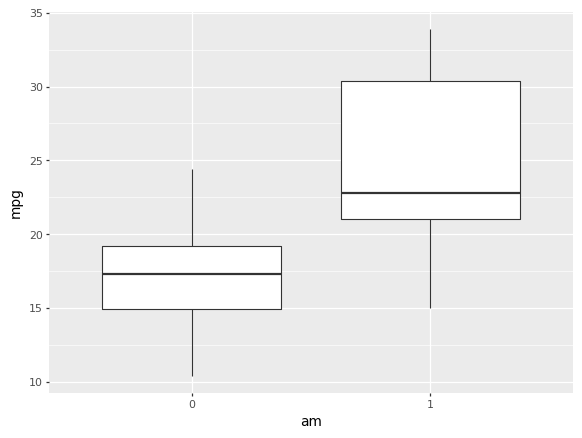

In [4]:
# Enter your code here
from plotnine import *

(ggplot(df, aes(x = "am", y = "mpg"))
 + geom_boxplot()
)

2\. What happens if you convert the `am` variable back to float values and then try to create the same plot as in the previous part? Explain the differences between the two plots.

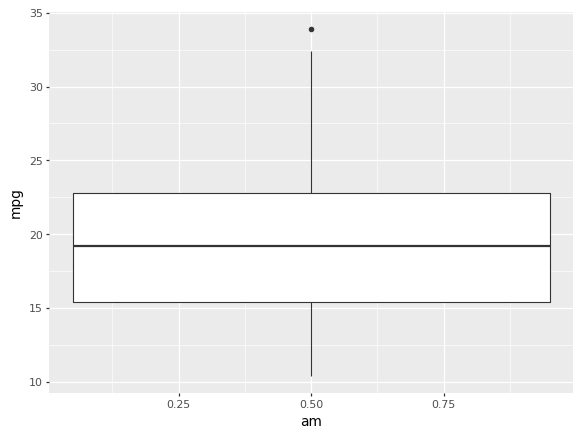

In [5]:
# Enter your code here
df["am"] = df["am"].astype(float)

(ggplot(df, aes(x = "am", y = "mpg"))
 + geom_boxplot()
)

**Answer:** With `am` as *text*, plotnine treats it as **categorical**: two side-by-side boxes, one per transmission type, with a labeled discrete axis. With `am` as *float*, plotnine treats it as **quantitative**: the x-axis becomes a number line and the grouping disappears — you get a single box for all 32 cars (ggplot has no groups to split on a continuous x). The variable *type* decided the plot, not the values.

3\. Create overlaid histograms of the `hp` variable for the different values of the `cyl` variable.

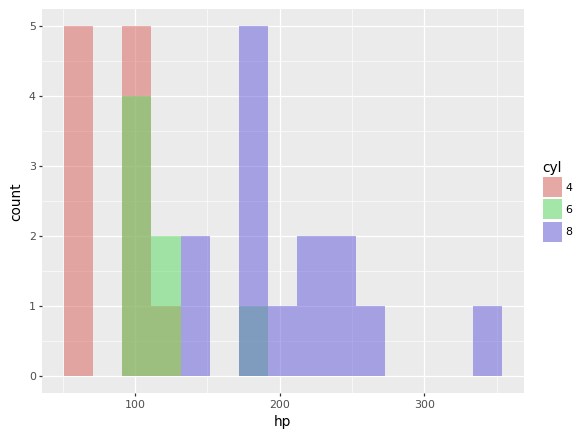

In [6]:
# Enter your code here
df["am"] = df["am"].astype(str)      # put am back to text

(ggplot(df, aes(x = "hp", fill = "cyl"))
 + geom_histogram(bins = 15, alpha = 0.5, position = "identity")
)

4\. What happens if you convert the `cyl` variable back to float values and then try to create the same plot as in the previous part? Explain the differences between the two plots.

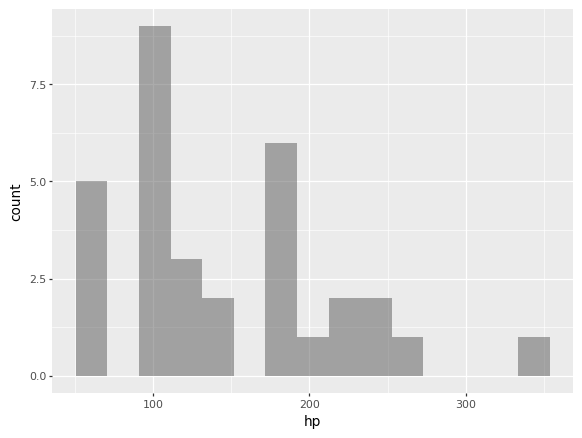

In [7]:
# Enter your code here
df["cyl"] = df["cyl"].astype(float)

(ggplot(df, aes(x = "hp", fill = "cyl"))
 + geom_histogram(bins = 15, alpha = 0.5, position = "identity")
)

**Answer:** With `cyl` as text, `fill` is **discrete**: three distinct colors and a legend with the levels 4, 6, 8 — three overlaid distributions you can compare. With `cyl` as float, `fill` becomes **continuous**: the legend turns into a gradient colorbar and the three groups are shaded along a gradient of one hue — much harder to tell apart. Categorical variables get discrete scales; quantitative variables get continuous scales.

5\. Choose a new `geometry` from the [data-to-viz website](https://www.data-to-viz.com/) or look in the [`plotnine` graph gallery](https://python-graph-gallery.com/plotnine/) for a graph that you'd like to explore using the `mtcars` dataset, and then create that graph. Share your graph with a classmate and discuss it's advantages and disadvantages.

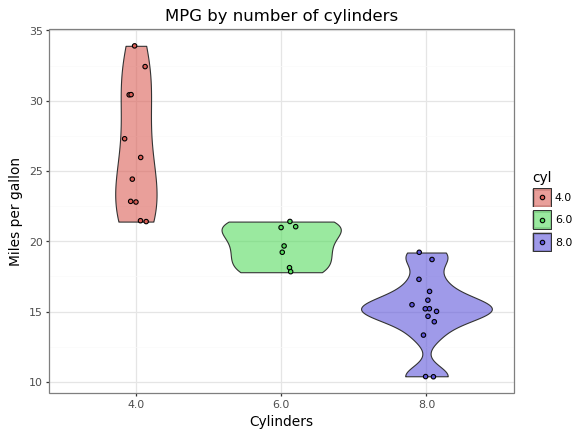

In [8]:
# Enter your code here
df["cyl"] = df["cyl"].astype(str)    # back to categorical

# A violin plot: like a boxplot, but shows the full shape of the distribution
(ggplot(df, aes(x = "cyl", y = "mpg", fill = "cyl"))
 + geom_violin(alpha = 0.6)
 + geom_jitter(width = 0.1)
 + labs(title = "MPG by number of cylinders", x = "Cylinders", y = "Miles per gallon")
 + theme_bw()
)

**Answer (one option):** A **violin plot** shows the whole shape of each distribution (advantage over a boxplot), but is harder to read for small groups — with 32 cars the bumps are mostly noise (disadvantage).

6\. Repeat the previous part for another graph that you'd like to explore using the `mtcars` dataset, and then create that graph. Share your graph with a classmate and discuss it's advantages and disadvantages.

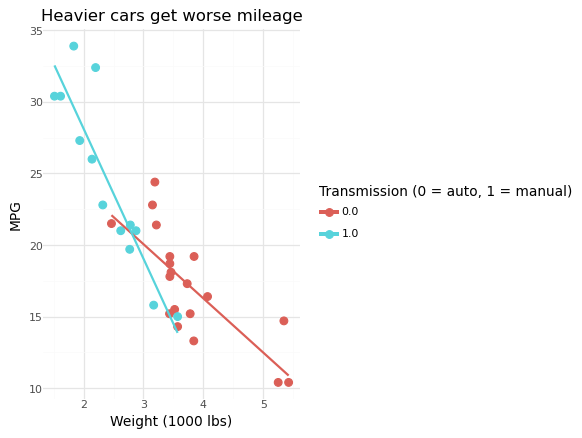

In [9]:
# Enter your code here
# A scatterplot with a trend line per transmission type
(ggplot(df, aes(x = "wt", y = "mpg", color = "am"))
 + geom_point(size = 3)
 + geom_smooth(method = "lm", se = False)
 + labs(title = "Heavier cars get worse mileage", x = "Weight (1000 lbs)", y = "MPG",
        color = "Transmission (0 = auto, 1 = manual)")
 + theme_minimal()
)

**Answer (one option):** Scatter + fitted lines shows the weight–mileage relationship *and* that manual cars in this data are mostly the lighter ones (advantage: two questions in one plot; disadvantage: with 32 points the two slopes are easily over-read).

## FEV Data

(You saw this data set in [GSB 518](https://kevin-davisross.quarto.pub/gsb518-notes/hw-09.html#problem-3).) Do non-smokers have better lungs than smokers? One measure of lung function is forced expiratory volume (FEV), the amount of air (in liters) an individual can exhale in the first second of forceful breath. Larger values of FEV are indicative of better functioning lungs. In a study, FEV was measured for a group of 654 subjects, along with whether they smoked and other variables like age (years). [Here is the data.](https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/FEV.csv)

[This plot](https://drive.google.com/file/d/1dm7U1cpVpHrbNZrBymOdmtkhMX3U7BwU/view?usp=sharing) was made using `plotly`. Use AI to help reproduce it using `plotnine`. Think in terms of the grammar of graphics and the design of the plot and write prompts like "The x-axis is mapped to Age". It might help to [try the two practice activities in Section 3.6.3 first](https://ds-ml-with-python.github.io/Course-Textbook/02-plotnine.html#try-it-out).


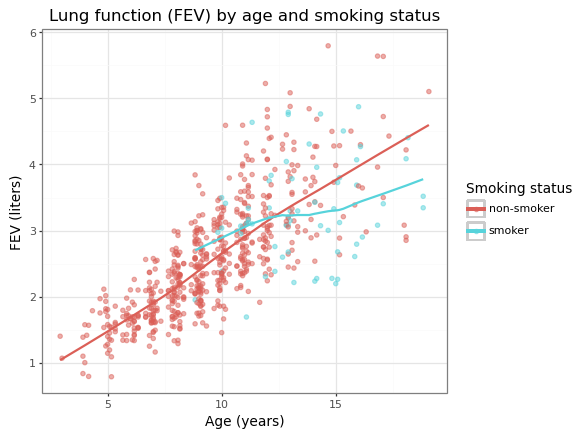

In [10]:
# Enter your code here
fev = pd.read_csv("https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/FEV.csv")
fev["Age (years)"] = fev["Age (months)"] / 12

(ggplot(fev, aes(x = "Age (years)", y = "FEV", color = "Smoking status"))
 + geom_point(alpha = 0.5)
 + geom_smooth(se = False)
 + labs(title = "Lung function (FEV) by age and smoking status",
        y = "FEV (liters)")
 + theme_bw()
)

**Answer / discussion:** At first glance smokers appear to have *better* lung function — their points and curve sit higher. The catch is **age**: only older kids smoke, and FEV grows with age (and height). Within comparable ages the smokers' curve flattens below the non-smokers' trend. This is a classic confounding example — exactly the kind of nuance a good plot exposes and a single group mean hides.

*Grammar-of-graphics prompts that reproduce this plot:* "x-axis is mapped to Age, y-axis to FEV, color to Smoking status; geometry is points plus a smooth trend line per color."

## Olympic Men's Gymnastics Data

[This file](https://raw.githubusercontent.com/mshsu/probasets/refs/heads/main/data/OlympicAllAround.csv) contains scores from the qualification and final rounds of the Olympic men's gymnastics all around competition from 2008 to 2020. (Thanks to Martin Hsu for scraping this data set.)

1\. Your goal will be to create a graphic which summarizes the distribution of scores across events and years, and any other features you want to add. But first...


This data is in "wide format" in that the scores are spread over six columns.

| Floor score | Pommel score | Rings score | Vault score | Pbar score | Hbar score |
|------------:|-------------:|------------:|------------:|-----------:|-----------:|
|        15.0 |         14.5 |        15.2 |        16.1 |       14.6 |       15.0 |


In order to produce some plots (and work with the grammar of graphics more fully), you might need to reformat the data so that it is "long format" with one column for score and a new column for "event".

| Event  | Score |
|--------|------:|
| Floor  |  15.0 |
| Pommel |  14.5 |
| Rings  |  15.2 |
| Vault  |  16.1 |
| Pbar   |  14.6 |
| Hbar   |  15.0 |

Create a new data frame with the scores in long format, with columns labeled "Event" and "Score". There are a few ways to do this, so see what you can find!


In [11]:
# YOUR CODE HERE
oly = pd.read_csv("https://raw.githubusercontent.com/mshsu/probasets/refs/heads/main/data/OlympicAllAround.csv")

event_cols = ["Floor Exercise", "Horse Vault", "Parallel Bars",
              "Horizontal Bar", "Rings", "Pommelled Horse"]

oly_long = oly.melt(id_vars = ["Pos", "Gymnast", "NOC", "Points", "Round", "Year"],
                    value_vars = event_cols,
                    var_name = "Event",
                    value_name = "Score")

print(oly.shape, "->", oly_long.shape)     # 6 score columns become 6x the rows
oly_long.head()

(351, 12) -> (2106, 8)


,Pos,Gymnast,NOC,Points,Round,Year,Event,Score
0,1.0,Danell Leyva,USA,91.265,Qualification,2012,Floor Exercise,15.100
1,2.0,David Belyavsky,RUS,90.832,Qualification,2012,Floor Exercise,15.100
2,3.0,Fabian HambÃ¼chen,GER,90.765,Qualification,2012,Floor Exercise,15.133
3,4.0,John Orozco,USA,90.597,Qualification,2012,Floor Exercise,15.166
4,5.0,Kristian Thomas,GBR,90.256,Qualification,2012,Floor Exercise,15.366


**Answer:** `.melt()` turns the six score columns into two: the old column *headers* become the `Event` variable and the old cell *values* become `Score`. 351 wide rows × 6 events = 2,106 long rows — one row per gymnast-event, which is what the grammar of graphics wants.

2\. Now create a graphic which summarizes the distribution of scores across events and years, and any other features you want to add. Be creative! Share your graph with a classmate and discuss why you designed it the way you did.

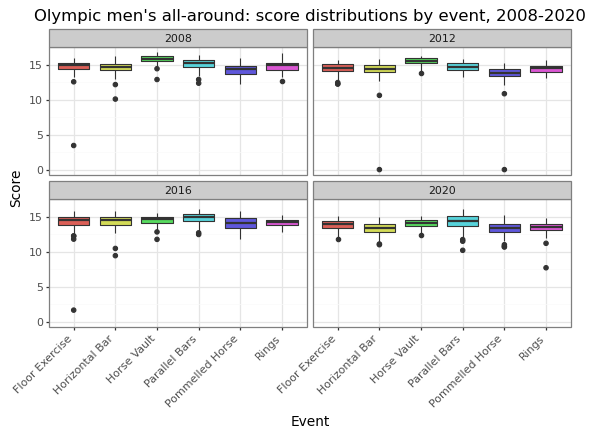

In [12]:
# YOUR CODE HERE
(ggplot(oly_long.dropna(subset = ["Score"]), aes(x = "Event", y = "Score", fill = "Event"))
 + geom_boxplot()
 + facet_wrap("Year")
 + scale_fill_discrete(guide = None)          # x-axis already names the events
 + labs(title = "Olympic men's all-around: score distributions by event, 2008-2020")
 + theme_bw()
 + theme(axis_text_x = element_text(angle = 45, hjust = 1))
)

**Answer (one option):** Boxplots of `Score` by `Event`, one panel per `Year`. Design choices: facets keep each Games comparable on the same axes; the fill legend is suppressed since the x-axis already labels events; angled labels keep the six event names readable. Vault consistently scores highest and pommel horse is the most variable — a story you cannot see in the wide table.